In [12]:
# 1) Core imports and configuration

import os
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
from gymnasium import spaces

# Ablation Output Directory ---
SAVE_DIR = "results/ablation2"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Results will be saved to: {SAVE_DIR}")
# ------------------------------------------

# EdgeSimPy — correct import pattern
try:
    from edge_sim_py import *
    import edge_sim_py as EDGESIMPY_MODULE
    # Verify Simulator is actually available after wildcard import
    if "Simulator" not in dir():
        raise ImportError("Simulator class not found after edge_sim_py wildcard import.")
    print(f"EdgeSimPy available: {EDGESIMPY_MODULE.__version__ if hasattr(EDGESIMPY_MODULE, '__version__') else 'version unknown'}")
except ImportError as e:
    raise ImportError(
        "EdgeSimPy is not installed or not visible in this environment.\n"
        "Run:  pip install git+https://github.com/EdgeSimPy/EdgeSimPy.git\n"
        "Then restart the kernel."
    ) from e

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

print(f"PyTorch:    {torch.__version__}")
print(f"Gymnasium:  {gym.__version__}")
print(f"Device:     {DEVICE}")

Results will be saved to: results/ablation2
EdgeSimPy available: 1.1.0
PyTorch:    2.10.0+cpu
Gymnasium:  1.2.3
Device:     cpu


In [13]:
# 2) Global configuration and infrastructure spec

@dataclass(frozen=True)
class GlobalConfig:
    # Infrastructure
    EDGE_SERVER_COUNT: int = 10
    CLOUD_SERVER_COUNT: int = 1
    EDGE_CPU_MIPS: float = 2000.0
    CLOUD_CPU_MIPS: float = 25000.0
    EDGE_CLOUD_BANDWIDTH_MBPS: float = 100.0

    # Task model
    TASK_SIZE_MB: float = 0.5
    TASK_COMPLEXITY_GIGACYCLES: float = 1.0

    # Paths
    RESULTS_DIR: str = SAVE_DIR
    SCENARIO_FILE: str = f"results/edgesimpy/ablation2.json"

    # RL defaults
    GAMMA: float = 0.99
    ACTOR_LR: float = 1e-4
    CRITIC_LR: float = 1e-4
    BATCH_SIZE: int = 64
    MEMORY_CAPACITY: int = 50_000

    # Experiment seeds
    SEEDS: Tuple[int, ...] = (10, 20, 30, 40, 50)

CONFIG = GlobalConfig()

# Expose seeds as a list for loops
EXPERIMENT_SEEDS = list(CONFIG.SEEDS)

Path(CONFIG.RESULTS_DIR).mkdir(parents=True, exist_ok=True)

@dataclass(frozen=True)
class InfrastructureSpec:
    edge_server_count: int          = CONFIG.EDGE_SERVER_COUNT
    cloud_server_count: int         = CONFIG.CLOUD_SERVER_COUNT
    edge_cpu_mips: float            = CONFIG.EDGE_CPU_MIPS
    cloud_cpu_mips: float           = CONFIG.CLOUD_CPU_MIPS
    edge_cloud_bandwidth_mbps: float = CONFIG.EDGE_CLOUD_BANDWIDTH_MBPS
    task_size_mb: float             = CONFIG.TASK_SIZE_MB
    task_complexity_gigacycles: float = CONFIG.TASK_COMPLEXITY_GIGACYCLES
    dataset_dir: str                = CONFIG.RESULTS_DIR
    dataset_file: str               = CONFIG.SCENARIO_FILE

INFRA = InfrastructureSpec()
print("Config and infrastructure spec ready.")
print(f"Results Directory: {CONFIG.RESULTS_DIR}")
print(f"Seeds: {EXPERIMENT_SEEDS}")
print(f"Device: {DEVICE}")

Config and infrastructure spec ready.
Results Directory: results/ablation2
Seeds: [10, 20, 30, 40, 50]
Device: cpu


In [14]:
# 3) Build and save EdgeSimPy scenario JSON (infrastructure only)

def build_edgesimpy_dataset(spec: InfrastructureSpec) -> Dict[str, Any]:
    edge_servers = [
        {
            "attributes": {
                "id": i + 1,
                "model_name": f"edge_{i + 1}",
                "cpu": spec.edge_cpu_mips,
            },
            "relationships": {},
        }
        for i in range(spec.edge_server_count)
    ]

    cloud_servers = [
        {
            "attributes": {
                "id": 10_000 + i + 1,
                "model_name": f"cloud_{i + 1}",
                "cpu": spec.cloud_cpu_mips,
            },
            "relationships": {},
        }
        for i in range(spec.cloud_server_count)
    ]

    dataset = {
        "metadata": {
            "edge_server_count": spec.edge_server_count,
            "cloud_server_count": spec.cloud_server_count,
            "edge_cloud_bandwidth_mbps": spec.edge_cloud_bandwidth_mbps,
            "task_size_mb": spec.task_size_mb,
            "task_complexity_gigacycles": spec.task_complexity_gigacycles,
        },
        "edge_servers": edge_servers,
        "cloud_servers": cloud_servers,
    }

    return dataset


EDGE_DATASET = build_edgesimpy_dataset(INFRA)

with open(INFRA.dataset_file, "w", encoding="utf-8") as f:
    json.dump(EDGE_DATASET, f, indent=2)

print(f"EdgeSimPy scenario written to: {INFRA.dataset_file}")
print(f"Edge servers: {INFRA.edge_server_count}, cloud servers: {INFRA.cloud_server_count}")

EdgeSimPy scenario written to: results/edgesimpy/ablation2.json
Edge servers: 10, cloud servers: 1


In [15]:
# 4) EdgeSimPy–Gymnasium environment wrapper (scheduling env) [REVISED: 5D STATIC]

class EdgeSimPySchedulingEnv(gym.Env):
    """Binary edge/cloud scheduling environment backed by EdgeSimPy.
    
    State space (5D) - ABLATION 2 (Static Weights):
        [queue_avg, workload_norm, pressure_norm, lat_weight, energy_cost_norm]
        - queue_avg       : current queue backlog (0–300)
        - workload_norm   : normalised task arrival rate (0–1)
        - pressure_norm   : load above baseline, normalised (0–1)
        - lat_weight      : ABLATION 2 -> Locked at 0.50 (0–1)
        - energy_cost_norm: last-step energy cost, normalised (0–1)
    """

    metadata = {"render_modes": ["human"], "render_fps": 1}

    def __init__(
        self,
        scenario_config=None,
        spec: InfrastructureSpec = INFRA,
        scenario_file: Optional[str] = None,
        render_mode: Optional[str] = None,
    ):
        super().__init__()

        self.spec = spec
        self.scenario_config = scenario_config
        self.scenario_file = scenario_file or getattr(CONFIG, "EDGESIMPY_SCENARIO_FILE", None)
        self.render_mode = render_mode

        # RL interface
        self.action_space = spaces.Discrete(2)          # 0 = edge, 1 = cloud
        self.observation_space = spaces.Box(            # 5D retained for architectural control
            low=np.array( [0.0,   0.0, 0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([300.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        # Internal state
        self.simulator: Optional[Simulator] = None
        self.pending_action: int   = 0
        self.episodelength: int    = 2000
        self.stepcount: int        = 0
        self.currentworkload: int  = 50
        self.queueavg: float       = 10.0
        self.last_latency_s: float = 0.0
        self.last_energy_j: float  = 0.0
        # <- CHANGED: Hardcoded to 0.50 to simulate standard static baselines
        self.current_lat_weight: float = 0.5   

    # ── Weight interface ──────────────────────────────────────────────────────

    def update_weights(self, lat_weight: float, eng_weight: float) -> None: 
        """ABLATION 2: Disabled to prevent dynamic weight controller updates."""
        pass 

    # ── EdgeSimPy integration helpers ─────────────────────────────────────────

    def _build_simulator(self) -> Optional[Simulator]:
        if self.scenario_file is None or not os.path.exists(self.scenario_file):
            return None
        try:
            sim = Simulator(
                tick_duration=1,
                tick_unit="seconds",
                resource_management_algorithm=self._resource_management_algorithm,
            )
            try:
                sim.initialize(input_file=self.scenario_file)
            except TypeError:
                sim.initialize(self.scenario_file)
            return sim
        except Exception:
            return None

    def _resource_management_algorithm(self, parameters=None):
        if parameters is None:
            parameters = {}

        action      = int(parameters.get("action", self.pending_action))
        target_tier = "edge" if action == 0 else "cloud"

        EdgeServer = getattr(EDGESIMPY_MODULE, "EdgeServer", None)
        Service    = getattr(EDGESIMPY_MODULE, "Service",    None)

        if EdgeServer is None or Service is None:
            return {"action": action, "target_tier": target_tier, "placements": 0}

        try:
            servers  = list(EdgeServer.all())
            services = list(Service.all())
        except Exception:
            return {"action": action, "target_tier": target_tier, "placements": 0}

        def is_tier(server, tier: str) -> bool:
            name = str(getattr(server, "model_name", "")).lower()
            if tier == "cloud":
                return "cloud" in name or int(getattr(server, "id", 0)) >= 10_000
            return "edge" in name or int(getattr(server, "id", 0)) < 10_000

        def free_cpu(server) -> float:
            total = float(getattr(server, "cpu", 0.0))
            used  = float(getattr(server, "cpu_demand",
                          getattr(server, "cpu_used", 0.0)))
            return total - used

        candidates = sorted(
            [s for s in servers if is_tier(s, target_tier)],
            key=free_cpu, reverse=True,
        )

        placements = 0
        for svc in services:
            if getattr(svc, "server", None) is not None:
                continue
            if bool(getattr(svc, "finished", False)):
                continue
            for srv in candidates:
                fn = getattr(srv, "provision", None)
                if callable(fn):
                    try:
                        fn(service=svc)
                    except TypeError:
                        try:
                            fn(svc)
                        except Exception:
                            continue
                    placements += 1
                    break

        return {"action": action, "target_tier": target_tier, "placements": placements}

    def _advance_simulator_one_tick(self) -> None:
        if self.simulator is None:
            return
        if hasattr(self.simulator, "step") and callable(self.simulator.step):
            self.simulator.step()
        elif hasattr(self.simulator, "run_step") and callable(self.simulator.run_step):
            self.simulator.run_step()

    def _get_workload(self, timestep: int) -> int:
        if self.scenario_config is None:
            return int(self.currentworkload)
        if hasattr(self.scenario_config, "workload_at"):
            return int(self.scenario_config.workload_at(timestep))
        raise AttributeError("ScenarioConfig must define workload_at()")

    # ── Analytical latency / energy model ────────────────────────────────────

    def _compute_metrics(self, action: int) -> Tuple[float, float]:
        edge_total_mips  = self.spec.edge_server_count  * self.spec.edge_cpu_mips
        cloud_total_mips = self.spec.cloud_server_count * self.spec.cloud_cpu_mips
        cycles           = self.spec.task_complexity_gigacycles * 1e9

        edge_compute_base_s  = cycles / (edge_total_mips  * 1e6)
        cloud_compute_base_s = cycles / (cloud_total_mips * 1e6)
        transmission_base_s  = (self.spec.task_size_mb * 8.0) / self.spec.edge_cloud_bandwidth_mbps

        edge_latency_s = edge_compute_base_s * (
            1.0 + self.queueavg / 80.0 + self.currentworkload / 250.0
        )
        cloud_latency_s = (transmission_base_s + cloud_compute_base_s) * (
            1.0 + self.queueavg / 220.0 + self.currentworkload / 400.0
        )

        edge_energy_j  = 1.6 * edge_latency_s  + 0.002  * self.currentworkload
        cloud_energy_j = 0.8 * cloud_latency_s + 0.0008 * self.currentworkload

        if int(action) == 0:
            return float(edge_latency_s), float(edge_energy_j)
        return float(cloud_latency_s), float(cloud_energy_j)

    def _build_state(self) -> np.ndarray: 
        workload_norm    = min(float(self.currentworkload) / 150.0, 1.0)
        pressure_norm    = min(max((float(self.currentworkload) - 50.0) / 100.0, 0.0), 1.0)
        energy_cost_norm = min(float(self.last_energy_j) / 5.0, 1.0)  
        # <- CHANGED: Uses the hardcoded 0.50 lat_weight
        return np.array(
            [float(self.queueavg), workload_norm, pressure_norm,
             self.current_lat_weight, energy_cost_norm],
            dtype=np.float32,
        )

    # ── Gymnasium API ─────────────────────────────────────────────────────────

    def reset(
        self,
        *,
        seed: Optional[int] = None,
        options: Optional[Dict[str, Any]] = None,
        episodelength: Optional[int] = None,
        initialworkload: Optional[int] = None,
    ):
        super().reset(seed=seed)
        if seed is not None:
            set_global_seed(seed)

        options = options or {}
        self.episodelength = int(
            episodelength if episodelength is not None
            else options.get("episodelength", self.episodelength)
        )
        self.currentworkload = int(
            initialworkload if initialworkload is not None
            else options.get("initialworkload", 50)
        )

        self.stepcount          = 0
        self.queueavg           = 10.0 + 0.10 * max(0, self.currentworkload - 50)
        self.last_latency_s     = 0.0
        self.last_energy_j      = 0.0
        self.pending_action     = 0
        self.current_lat_weight = 0.5   # <- CHANGED: Reset ensures it stays at 0.50

        self.simulator = self._build_simulator()

        obs  = self._build_state()
        info = {
            "queueavg":         float(self.queueavg),
            "workloadlevel":    int(self.currentworkload),
            "selectedlatencys": float(self.last_latency_s),
            "selectedenergyj":  float(self.last_energy_j),
            "latencyreward":    float(-self.last_latency_s),
            "energyreward":     float(-self.last_energy_j),
        }
        return obs, info

    def step(self, action: int, workloadlevel: Optional[int] = None):
        action = int(action)
        if not self.action_space.contains(action):
            raise ValueError(f"Invalid action: {action}")

        self.pending_action = action

        if workloadlevel is not None:
            self.currentworkload = int(workloadlevel)
        else:
            self.currentworkload = self._get_workload(self.stepcount)

        offload_relief = 6.0 if action == 1 else 0.0
        queue_next = (
            0.90 * self.queueavg
            + 0.18 * self.currentworkload
            - 8.0
            - offload_relief
        )
        self.queueavg = float(np.clip(queue_next, 0.0, 300.0))

        self.last_latency_s, self.last_energy_j = self._compute_metrics(action)

        latency_reward = -float(self.last_latency_s)
        energy_reward  = -float(self.last_energy_j)
        scalar_reward  = 0.5 * latency_reward + 0.5 * energy_reward

        scheduling_info = self._resource_management_algorithm(
            parameters={"action": self.pending_action}
        )
        self._advance_simulator_one_tick()

        self.stepcount += 1
        terminated = False
        truncated  = self.stepcount >= self.episodelength

        obs  = self._build_state()
        info = {
            "queueavg":         float(self.queueavg),
            "workloadlevel":    int(self.currentworkload),
            "selectedlatencys": float(self.last_latency_s),
            "selectedenergyj":  float(self.last_energy_j),
            "latencyreward":    float(latency_reward),
            "energyreward":     float(energy_reward),
            "placements":       int(scheduling_info.get("placements", 0)),
            "targettier":       scheduling_info.get("target_tier", "edge"),
        }

        return obs, float(scalar_reward), terminated, truncated, info

    def render(self):
        if self.render_mode == "human":
            print(
                f"t={self.stepcount} "
                f"workload={self.currentworkload} "
                f"queue={self.queueavg:.2f} "
                f"latency={self.last_latency_s:.4f}s "
                f"energy={self.last_energy_j:.4f}J "
                f"lat_weight={self.current_lat_weight:.3f}"
            )

    def close(self):
        self.simulator = None

print("Environment wrapper ready:", EdgeSimPySchedulingEnv.__name__)

Environment wrapper ready: EdgeSimPySchedulingEnv


In [16]:
# 5) Actor–Critic neural architecture for MOPER [IDENTICAL FOR ABLATION 2]

@dataclass(frozen=True)
class ActorCriticHyperParams:
    actor_learning_rate: float = CONFIG.ACTOR_LR
    critic_learning_rate: float = CONFIG.CRITIC_LR
    gamma: float = CONFIG.GAMMA
    batch_size: int = CONFIG.BATCH_SIZE
    memory_capacity: int = CONFIG.MEMORY_CAPACITY

class MOPERActorCriticNet(nn.Module):
    """
    Shared state encoder, one policy head, two value heads:
    - latency value
    - energy value
    
    ABLATION 2: 
    This architecture remains strictly identical to the full MOPER. 
    Retaining dual heads ensures the network capacity is unchanged and 
    provides the dual TD-errors required by the weight-aware PER buffer.
    """

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.actor_head = nn.Linear(hidden_dim, action_dim)
        self.latency_value_head = nn.Linear(hidden_dim, 1)
        self.energy_value_head = nn.Linear(hidden_dim, 1)

    def forward(self, state: torch.Tensor):
        z = self.shared(state)
        logits = self.actor_head(z)
        latency_value = self.latency_value_head(z)
        energy_value = self.energy_value_head(z)
        return logits, latency_value, energy_value

    def action_distribution(self, state: torch.Tensor):
        logits, _, _ = self.forward(state)
        return torch.distributions.Categorical(logits=logits)

In [17]:
# 6) [REVISED FOR ABLATION 2: STATIC CONTROLLER]

@dataclass(frozen=True)
class WeightControlConfig:
    # ABLATION 2: Dynamic config parameters removed to prevent accidental usage.
    # Hardcoded to 0.50 to mirror standard scalarization baselines.
    static_latency_weight: float = 0.50
    static_energy_weight: float  = 0.50

class StaticWeightController:
    """
    ABLATION 2: Replaces the DynamicWeightController.
    Ignores all environment feedback (EMA, Ratios, Queue Pressure).
    Permanently returns fixed 0.50 weights to test the artifact's failure 
    mode under static prioritization constraints.
    """

    def __init__(self, config: WeightControlConfig = WeightControlConfig()):
        self.config = config
        self.alpha = float(config.static_latency_weight)
        self.beta  = float(config.static_energy_weight)

    def update_from_feedback(
        self,
        latency_cost: float,
        energy_cost: float,
        current_queue_avg: float,
    ) -> Tuple[float, float]:
        
        # ABLATION 2: Feedback is completely ignored.
        # Returns static 0.50/0.50 to force baseline-equivalent blindness.
        return self.alpha, self.beta

    def select_weights(self, current_queue_avg: float) -> Tuple[float, float]:
        """Passive weight selection without feedback — used for inference only."""
        return self.alpha, self.beta

# To prevent breaking downstream agent code that might still call DynamicWeightController
DynamicWeightController = StaticWeightController

print("StaticWeightController (Ablation 2) ready. Dynamic shifting DISABLED.")

StaticWeightController (Ablation 2) ready. Dynamic shifting DISABLED.


In [18]:
# 7) Multi-objective prioritized experience replay (MOPER buffer) [IDENTICAL FOR ABLATION 2]

from dataclasses import dataclass
import numpy as np

@dataclass
class ObjectiveTransition:
    state: np.ndarray
    action: int
    latency_reward: float
    energy_reward: float
    scalar_reward: float
    next_state: np.ndarray
    done: bool
    latency_weight: float  # ABLATION 2: Will constantly receive 0.50
    energy_weight: float   # ABLATION 2: Will constantly receive 0.50

class PrioritizedObjectiveReplayBuffer:
    """
    Stores per-objective rewards and priorities.
    Priority is based on combined latency/energy TD components.
    
    ABLATION 2:
    This buffer is completely untouched. It will process the static 0.50 
    weights fed to it, proving that weight-aware PER fails to adapt if the 
    underlying weight controller is disabled.
    """

    def __init__(self, capacity: int, alpha: float = 0.6, beta: float = 0.4, eps: float = 1e-6):
        if capacity <= 0:
            raise ValueError("capacity must be positive")
        self.capacity = int(capacity)
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.eps = float(eps)

        self.memory: list[ObjectiveTransition] = []
        self.priorities = np.zeros(self.capacity, dtype=np.float32)
        self.pos = 0

    def __len__(self) -> int:
        return len(self.memory)

    def max_priority(self) -> float:
        if not self.memory:
            return 1.0
        return float(np.max(self.priorities[: len(self.memory)]))

    def add(self, transition: ObjectiveTransition, priority: float = 1.0) -> None:
        p = max(float(priority), self.eps)
        if len(self.memory) < self.capacity:
            self.memory.append(transition)
        else:
            self.memory[self.pos] = transition
        self.priorities[self.pos] = p
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size: int):
        if batch_size > len(self.memory):
            raise ValueError("batch_size cannot exceed current buffer size")

        valid_prio = np.maximum(self.priorities[: len(self.memory)], self.eps)
        scaled = np.power(valid_prio, self.alpha)
        total = float(scaled.sum())
        if not np.isfinite(total) or total <= self.eps:
            probs = np.full(len(self.memory), 1.0 / len(self.memory), dtype=np.float32)
        else:
            probs = (scaled / total).astype(np.float32)

        indices = np.random.choice(len(self.memory), size=batch_size, replace=False, p=probs)
        batch = [self.memory[i] for i in indices]

        is_weights = np.power(len(self.memory) * probs[indices] + self.eps, -self.beta)
        is_weights = (is_weights / is_weights.max()).astype(np.float32)

        return batch, indices.astype(np.int64), is_weights

    def update_priorities(self, indices, priorities) -> None:
        for idx, p in zip(indices, priorities):
            self.priorities[int(idx)] = max(float(p), self.eps)

    def boost_all_priorities(self, factor: float = 2.0) -> None:
        """
        Multiply all stored priorities by factor when a regime change is detected.
        Forces the buffer to re-expose all past experiences under the new weights.
        """
        if len(self.memory) == 0:
            return
        n = len(self.memory)
        # Cap at max_priority to prevent runaway values
        current_max = self.max_priority()
        self.priorities[:n] = np.minimum(self.priorities[:n] * factor, current_max * factor)

print("The artefact buffer ready.")

The artefact buffer ready.


In [19]:
# 8) MOPERActorCriticAgent —  artefact [CORRECTED METADATA]

from dataclasses import dataclass
from typing import Dict, Optional, Tuple
import numpy as np
import torch

@dataclass(frozen=True)
class MOPERHyperParams:
    actor_lr: float = CONFIG.ACTOR_LR
    critic_lr: float = CONFIG.CRITIC_LR
    gamma: float = CONFIG.GAMMA
    batch_size: int = CONFIG.BATCH_SIZE
    memory_capacity: int = CONFIG.MEMORY_CAPACITY
    per_alpha: float = 0.6       # PER priority exponent
    per_beta: float = 0.4        # IS-weight exponent
    per_eps: float = 1e-6        # floor for zero priority
    grad_clip_norm: float = 0.5

class MOPERActorCriticAgent:
    """
    Multi-Objective Actor-Critic with weight-aware Prioritized Experience Replay.
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int = 2,
        hp: MOPERHyperParams = MOPERHyperParams(),
        seed: Optional[int] = None,
    ):
        if state_dim <= 0 or action_dim <= 0:
            raise ValueError("state_dim and action_dim must be positive")
        self.hp = hp
        self.device = DEVICE

        self.net = MOPERActorCriticNet(state_dim, action_dim).to(self.device)

        self.actor_optimizer = torch.optim.Adam(
            list(self.net.shared.parameters()) + list(self.net.actor_head.parameters()),
            lr=hp.actor_lr,
        )
        self.critic_optimizer = torch.optim.Adam(
            list(self.net.shared.parameters())
            + list(self.net.latency_value_head.parameters())
            + list(self.net.energy_value_head.parameters()),
            lr=hp.critic_lr,
        )

        self.buffer = PrioritizedObjectiveReplayBuffer(
            capacity=hp.memory_capacity, alpha=hp.per_alpha, beta=hp.per_beta, eps=hp.per_eps,
        )
        
        self.weight_controller = DynamicWeightController()
        self.latency_weight: float = self.weight_controller.alpha
        self.energy_weight: float = self.weight_controller.beta

        # <- CHANGED: Moved from @property to a standard mutable dictionary attribute
        self.experiment_metadata: Dict[str, object] = {
            "algorithm": "MOPER",
            "actor_lr": self.hp.actor_lr,
            "critic_lr": self.hp.critic_lr,
            "gamma": self.hp.gamma,
            "batch_size": self.hp.batch_size,
            "memory_capacity": self.hp.memory_capacity,
            "per_alpha": self.hp.per_alpha,
            "per_beta": self.hp.per_beta,
        }

        if seed is not None:
            set_global_seed(seed)

    def act(self, state: np.ndarray) -> int:
        state_t = torch.tensor(np.asarray(state, dtype=np.float32), dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            dist = self.net.action_distribution(state_t)
        return int(dist.sample().item())

    def remember(self, state: np.ndarray, action: int, latency_reward: float, energy_reward: float, next_state: np.ndarray, done: bool) -> None:
        scalar_reward = self.latency_weight * latency_reward + self.energy_weight * energy_reward
        transition = ObjectiveTransition(
            state=np.asarray(state, dtype=np.float32), action=int(action),
            latency_reward=float(latency_reward), energy_reward=float(energy_reward),
            scalar_reward=float(scalar_reward), next_state=np.asarray(next_state, dtype=np.float32),
            done=bool(done), latency_weight=self.latency_weight, energy_weight=self.energy_weight,
        )
        self.buffer.add(transition, priority=self.buffer.max_priority())

    def update_weights(self, latency_cost: float, energy_cost: float, queue_avg: float, regime_change_threshold: float = 0.08, regime_boost_factor: float = 2.0) -> Tuple[float, float]:
        old_alpha = self.latency_weight
        self.latency_weight, self.energy_weight = self.weight_controller.update_from_feedback(latency_cost=latency_cost, energy_cost=energy_cost, current_queue_avg=queue_avg)
        delta_alpha = abs(self.latency_weight - old_alpha)
        if delta_alpha > regime_change_threshold and len(self.buffer) > 0:
            self.buffer.boost_all_priorities(factor=regime_boost_factor)
        return self.latency_weight, self.energy_weight

    def train_step(self) -> Dict[str, float]:
        if len(self.buffer) < self.hp.batch_size:
            return dict(updated=False, actor_loss=float("nan"), critic_loss=float("nan"), td_error=float("nan"), td_lat=float("nan"), td_eng=float("nan"), replay_priority=float("nan"))

        batch, indices, is_weights = self.buffer.sample(self.hp.batch_size)

        states      = torch.tensor(np.array([t.state       for t in batch], dtype=np.float32), dtype=torch.float32, device=self.device)
        actions     = torch.tensor([t.action      for t in batch], dtype=torch.long,    device=self.device)
        lat_rewards = torch.tensor([t.latency_reward for t in batch], dtype=torch.float32, device=self.device)
        eng_rewards = torch.tensor([t.energy_reward  for t in batch], dtype=torch.float32, device=self.device)
        next_states = torch.tensor(np.array([t.next_state  for t in batch], dtype=np.float32), dtype=torch.float32, device=self.device)
        dones       = torch.tensor([float(t.done)    for t in batch], dtype=torch.float32, device=self.device)
        stored_lw   = torch.tensor([t.latency_weight for t in batch], dtype=torch.float32, device=self.device)
        stored_ew   = torch.tensor([t.energy_weight  for t in batch], dtype=torch.float32, device=self.device)
        isw         = torch.tensor(is_weights, dtype=torch.float32, device=self.device)

        logits, lat_vals, eng_vals = self.net(states)
        lat_vals, eng_vals = lat_vals.squeeze(-1), eng_vals.squeeze(-1)

        with torch.no_grad():
            _, next_lat, next_eng = self.net(next_states)
            next_lat, next_eng = next_lat.squeeze(-1), next_eng.squeeze(-1)

        lat_targets = lat_rewards + self.hp.gamma * (1.0 - dones) * next_lat
        eng_targets = eng_rewards + self.hp.gamma * (1.0 - dones) * next_eng

        td_lat    = lat_targets - lat_vals
        td_eng    = eng_targets - eng_vals
        td_scalar = stored_lw * td_lat + stored_ew * td_eng

        critic_loss = (isw * (stored_lw * td_lat.pow(2) + stored_ew * td_eng.pow(2))).mean()

        dist      = torch.distributions.Categorical(logits=logits)
        log_probs = dist.log_prob(actions)
        td_scalar_clamped = td_scalar.detach().clamp(-5.0, 5.0)
        actor_loss = -(log_probs * td_scalar_clamped * isw).mean() - 0.01 * dist.entropy().mean()

        total_loss = actor_loss + critic_loss

        self.actor_optimizer.zero_grad()
        self.critic_optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.net.parameters(), self.hp.grad_clip_norm)
        self.actor_optimizer.step()
        self.critic_optimizer.step()

        current_lw = torch.tensor(self.latency_weight, dtype=torch.float32, device=self.device)
        weight_mismatch = 1.0 + torch.abs(stored_lw - current_lw)
        
        base_joint_td = torch.sqrt(td_lat.pow(2) + td_eng.pow(2))
        priority_values = (base_joint_td * weight_mismatch).detach().cpu().numpy()
        self.buffer.update_priorities(indices, priority_values)

        return dict(
            updated=True, actor_loss=float(actor_loss.item()), critic_loss=float(critic_loss.item()),
            td_error=float(torch.abs(td_scalar).mean().detach().cpu().item()),
            td_lat=float(torch.abs(td_lat).mean().detach().cpu().item()),
            td_eng=float(torch.abs(td_eng).mean().detach().cpu().item()),
            replay_priority=float(np.mean(priority_values)),
        )

print("MOPERActorCriticAgent ready.")

MOPERActorCriticAgent ready.


In [20]:
# 9) Scenario configurations [Ablation part 2]

from dataclasses import dataclass, field
from typing import List, Tuple

@dataclass
class ScenarioConfig:
    name: str
    total_timesteps: int
    workload_schedule: List[Tuple[int, int, int]]  # (start, end, tasks_per_step)
    spike_windows: List[Tuple[int, int]] = field(default_factory=list)

    def workload_at(self, timestep: int) -> int:
        for start, end, level in self.workload_schedule:
            if start <= timestep < end:
                return level
        return self.workload_schedule[-1][2]

    def phase_from(self, timestep: int) -> str:
        for start, end in self.spike_windows:
            if start <= timestep < end:
                return "spike"
        return "normal"

# built for ABLATION2 Multi-Spike Stress Test
ABLATION2 = ScenarioConfig(
    name="ABLATION2_repeated_spike",
    total_timesteps=3000,
    workload_schedule=[
        (0,    500,  50),    # Initial baseline
        (500,  800,  150),   # Spike 1: Trigger first regime change
        (800,  1500, 50),    # Cool-down 1: Trigger recovery regime
        (1500, 1800, 150),   # Spike 2: Test against catastrophic forgetting
        (1800, 2200, 50),    # Cool-down 2: Test recovery stability
        (2200, 2500, 150),   # Spike 3: Final stress burst
        (2500, 3000, 50),    # Final recovery
    ],
    spike_windows=[
        (500, 800), 
        (1500, 1800), 
        (2200, 2500)
    ],
)

print("Scenarios ready:", ABLATION2.name)

Scenarios ready: ABLATION2_repeated_spike


In [21]:
# 10) Ablation part2-Training runner

import csv
from pathlib import Path
from typing import Dict, List

STEP_LOG_COLUMNS = [
    "timestep", "seed", "scenario", "agent",
    "workload_level", "queue_avg", "action",
    "selected_latency_s", "selected_energy_j",
    "latency_weight", "energy_weight", "td_lat", "td_eng",
    "reward", "actor_loss", "critic_loss",
    "td_error", "replay_priority", "phase",
]

def run_episode(
    agent, 
    scenario, 
    seed: int,
    save_dir: str = "results/ablation2", 
) -> Dict:
    set_global_seed(seed)
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    # Extract the correct algorithm name dynamically
    agent_name = agent.experiment_metadata.get("algorithm", type(agent).__name__).upper()

    env = EdgeSimPySchedulingEnv(scenario_config=scenario)
    state, _ = env.reset(seed=seed, episodelength=scenario.total_timesteps,
                         initialworkload=scenario.workload_at(0))

    rows: List[Dict] = []
    total_reward = 0.0

    for t in range(scenario.total_timesteps):
        workload = scenario.workload_at(t)
        
        # Action selection based on current 5D state
        action = agent.act(state)
        next_state, _, terminated, truncated, info = env.step(action, workloadlevel=workload)

        lat_r = float(info["latencyreward"])
        eng_r = float(info["energyreward"])

        # Store transition in memory buffer
        agent.remember(state, action, lat_r, eng_r, next_state,
                       bool(terminated or truncated))

        # ABLATION 2: Executes via StaticWeightController to return 0.50/0.50
        lw, ew = agent.update_weights(
            latency_cost=-lat_r,
            energy_cost=-eng_r,
            queue_avg=float(info["queueavg"]),
        )
        
        # Push the newly calculated weights back into the environment (Ignored in Env)
        env.update_weights(lw, ew)
        
        # Re-build next_state so the 4th dimension (lat_weight) is instantly correct (Fixed at 0.50)
        next_state = env._build_state()

        # Execute training step (gradient descent + priority update)
        losses = agent.train_step()
        
        # Compute scalar reward purely for logging
        reward = lw * lat_r + ew * eng_r
        total_reward += reward

        rows.append(dict(
            timestep=t, seed=seed,
            scenario=scenario.name, 
            agent=agent_name, 
            workload_level=workload,
            queue_avg=float(info["queueavg"]),
            action=action,
            selected_latency_s=float(info["selectedlatencys"]),
            selected_energy_j=float(info["selectedenergyj"]),
            latency_weight=lw, energy_weight=ew,
            reward=reward,
            actor_loss=losses.get("actor_loss", float("nan")),
            critic_loss=losses.get("critic_loss", float("nan")),
            td_error=losses.get("td_error", float("nan")),
            td_lat=losses.get("td_lat", float("nan")),
            td_eng=losses.get("td_eng", float("nan")),
            replay_priority=losses.get("replay_priority", float("nan")),
            phase=scenario.phase_from(t),
        ))

        state = next_state
        if terminated or truncated:
            break

    env.close()
    return dict(rows=rows, total_reward=total_reward, steps=len(rows))

print("Ablation part2 Runner ready.")

Ablation part2 Runner ready.


In [22]:
# 11) Ablation2 Execution: Ablated MOPER Agent (No Dynamic weight adjustment mechanism) [CORRECTED]

import pandas as pd
from pathlib import Path

SAVEDIR = "results/ablation2/"
Path(SAVEDIR).mkdir(parents=True, exist_ok=True)

print("Starting ABLATED MOPER Agent execution (Static Weight) for Ablation 2...")

STATE_DIM = 5
ACTION_DIM = 2

for seed in EXPERIMENT_SEEDS:
    print(f"Running Ablated MOPER (NO_WSHIFT) Agent - Seed: {seed}")
    
    ablated_agent = MOPERActorCriticAgent(
        state_dim=STATE_DIM, 
        action_dim=ACTION_DIM, 
        hp=MOPERHyperParams(),
        seed=seed,
    )
    
    # Update the dictionary key instead of overwriting the whole property
    ablated_agent.experiment_metadata["algorithm"] = "MOPER_NO_WSHIFT"
    
    res = run_episode(
        agent=ablated_agent, 
        scenario=ABLATION2, 
        seed=seed, 
        save_dir=SAVEDIR,
    )
    
    df_seed = pd.DataFrame(res["rows"])
    seed_csv_path = Path(SAVEDIR) / f"{ABLATION2.name}_moper_no_wshift_seed_{seed}.csv"
    df_seed.to_csv(seed_csv_path, index=False)
    
    print(f"  -> Saved: {seed_csv_path.name} | Reward: {res['total_reward']:.4f}")

print("Execution complete. All Ablated MOPER per-seed CSVs saved.")

Starting ABLATED MOPER Agent execution (Static Weight) for Ablation 2...
Running Ablated MOPER (NO_WSHIFT) Agent - Seed: 10
  -> Saved: ABLATION2_repeated_spike_moper_no_wshift_seed_10.csv | Reward: -395.6016
Running Ablated MOPER (NO_WSHIFT) Agent - Seed: 20
  -> Saved: ABLATION2_repeated_spike_moper_no_wshift_seed_20.csv | Reward: -395.4858
Running Ablated MOPER (NO_WSHIFT) Agent - Seed: 30
  -> Saved: ABLATION2_repeated_spike_moper_no_wshift_seed_30.csv | Reward: -395.1482
Running Ablated MOPER (NO_WSHIFT) Agent - Seed: 40
  -> Saved: ABLATION2_repeated_spike_moper_no_wshift_seed_40.csv | Reward: -394.7899
Running Ablated MOPER (NO_WSHIFT) Agent - Seed: 50
  -> Saved: ABLATION2_repeated_spike_moper_no_wshift_seed_50.csv | Reward: -394.9525
Execution complete. All Ablated MOPER per-seed CSVs saved.


In [23]:
# Cell 12 --- Consolidate Per-Seed CSVs into Single Benchmark File (ABLATION 2)

import pandas as pd
from pathlib import Path
import re

S3_BENCH_DIR = Path("results/scenario3/")
ABLATION2_BENCH_DIR = Path("results/ablation2/")

# Gather target CSVs from both respective directories
s3_files = list(S3_BENCH_DIR.glob("*_seed_*.csv"))
abl2_files = list(ABLATION2_BENCH_DIR.glob("*_seed_*.csv"))

all_dfs = []

# 1. Process Full Artefact (MOPER) from Scenario 3
for f in s3_files:
    filename = f.name.lower()
    # Ensure we only grab the full MOPER, ignoring baselines or ablation variants
    if "moper" in filename and "no_" not in filename:
        df = pd.read_csv(f)
        df['agent'] = "MOPER"
        
        seed_match = re.search(r'_seed_(\d+)', filename)
        if seed_match:
            df['seed'] = int(seed_match.group(1))
            
        all_dfs.append(df)

# 2. Process Ablated Artefact (MOPER_NO_WSHIFT) from Ablation 2
for f in abl2_files:
    filename = f.name.lower()
    # Target the strictly static weight ablation agent
    if "moper_no_wshift" in filename:
        df = pd.read_csv(f)
        df['agent'] = "MOPER_NO_WSHIFT"
        
        seed_match = re.search(r'_seed_(\d+)', filename)
        if seed_match:
            df['seed'] = int(seed_match.group(1))
            
        all_dfs.append(df)

if not all_dfs:
    print("Error: No MOPER or MOPER_NO_WSHIFT CSVs found across directories.")
else:
    df_bench = pd.concat(all_dfs, ignore_index=True)
    
    # Save the consolidated raw data in the Ablation 2 directory
    raw_path = ABLATION2_BENCH_DIR / "ablation2_benchmark_raw.csv"
    df_bench.to_csv(raw_path, index=False)
    
    total_files = len(all_dfs)
    print(f"Consolidated {total_files} files into {raw_path}")
    print(f"Total rows: {len(df_bench)} | Agents recorded: {df_bench['agent'].unique()}")

Consolidated 10 files into results\ablation2\ablation2_benchmark_raw.csv
Total rows: 30000 | Agents recorded: <StringArray>
['MOPER', 'MOPER_NO_WSHIFT']
Length: 2, dtype: str


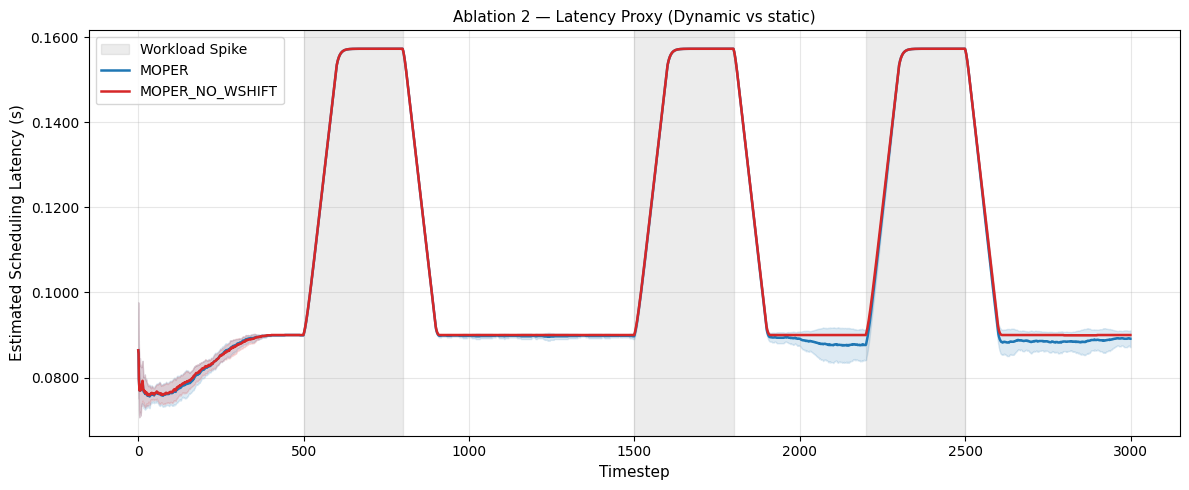

In [29]:
# Cell 13 --- SECONDARY METRIC: Estimated Scheduling Latency (REVISED)
# Applies to MOPER and MOPER_NO_WSHIFT under Ablation 2
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from pathlib import Path

ABLATION2_BENCH_DIR = "results/ablation2/"

# Configuration
SMOOTH = 100  # Filters noise while preserving spike response shape

# CORRECTION: Removed S3 baselines, added ablated agent
COLORS = {
    'MOPER': '#1f77b4',         # Blue
    'MOPER_NO_WSHIFT': '#d62728'   # Red
}

# Spike boundaries for the repeated spike scenario
SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# CORRECTION: Load the Cell 12 consolidated benchmark file
df = pd.read_csv(f"{ABLATION2_BENCH_DIR}/ablation2_benchmark_raw.csv")

# Handle column name variations
LATENCY_COL = 'selected_latency_s' if 'selected_latency_s' in df.columns else 'latency_s'

fig, ax = plt.subplots(figsize=(12, 5))

for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty:
        print(f"Warning: No data found for {agent_name}")
        continue
        
    # <- CORRECTED: Group by timestep first so the index is unequivocally chronological
    pivot = sub.groupby(['seed', 'timestep'])[LATENCY_COL].mean().unstack(level='seed')
    
    # Smooth chronologically down the rows
    smoothed = pivot.rolling(SMOOTH, min_periods=1)
    
    # Average across the seed columns
    m = smoothed.mean().mean(axis=1)
    s = smoothed.mean().std(axis=1)
    
    display_label = agent_name
    
    ax.plot(m.index, m.values, label=display_label, color=color, lw=1.8)
    ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.15)

ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel('Estimated Scheduling Latency (s)', fontsize=11)

# Update title for Ablation 2 context
ax.set_title('Ablation 2 — Latency Proxy (Dynamic vs static)', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='upper left')

ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

plt.tight_layout()

# Save to directory with correct filename
Path(ABLATION2_BENCH_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{ABLATION2_BENCH_DIR}/ablation2_latency_secondary.png", dpi=150)
plt.show()

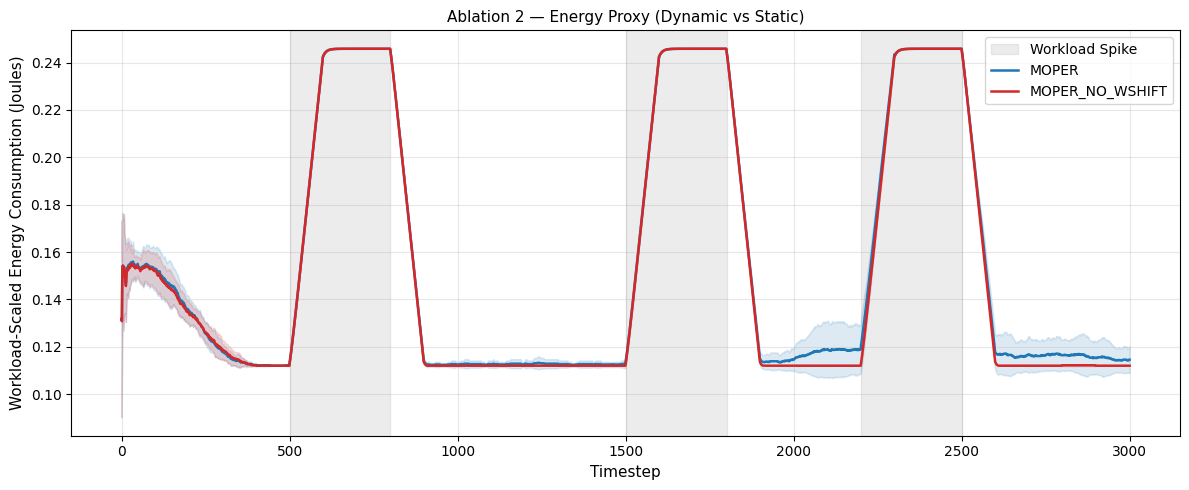

In [25]:
# Cell 14 --- SECONDARY METRIC: Workload-Scaled Energy Consumption (REVISED)
# Applies to MOPER and MOPER_NO_WSHIFT under Ablation 2
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ABLATION2_BENCH_DIR = "results/ablation2/"
SMOOTH = 100

# CORRECTION: Replaced S3 baselines with the ablated agent
COLORS = {
    'MOPER': '#1f77b4',         # Blue
    'MOPER_NO_WSHIFT': '#d62728'   # Red
}

SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# Load the Cell 12 consolidated benchmark file
df = pd.read_csv(f"{ABLATION2_BENCH_DIR}/ablation2_benchmark_raw.csv")

# Handle potential column name variations
ENERGY_COL = 'selected_energy_j' if 'selected_energy_j' in df.columns else 'energy_j'

fig, ax = plt.subplots(figsize=(12, 5))

for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: 
        print(f"Warning: No data found for {agent_name}")
        continue
    
    # <- CORRECTED: Group by timestep first so the index is unequivocally chronological
    pivot = sub.groupby(['timestep', 'seed'])[ENERGY_COL].mean().unstack(level='seed')
    
    # Smooth chronologically down the rows
    smoothed = pivot.rolling(SMOOTH, min_periods=1)
    
    # Average across the seed columns
    m = smoothed.mean().mean(axis=1)
    s = smoothed.mean().std(axis=1)
    
    display_label = agent_name
    
    ax.plot(m.index, m.values, label=display_label, color=color, lw=1.8)
    ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.15)

ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel('Workload-Scaled Energy Consumption (Joules)', fontsize=11)

# Update title for Ablation 2 context
ax.set_title('Ablation 2 — Energy Proxy (Dynamic vs Static)', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='upper right')

ax.grid(alpha=0.3)
plt.tight_layout()

# Save to correct directory with correct ablation filename
Path(ABLATION2_BENCH_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{ABLATION2_BENCH_DIR}/ablation2_energy_secondary.png", dpi=150)
plt.show()

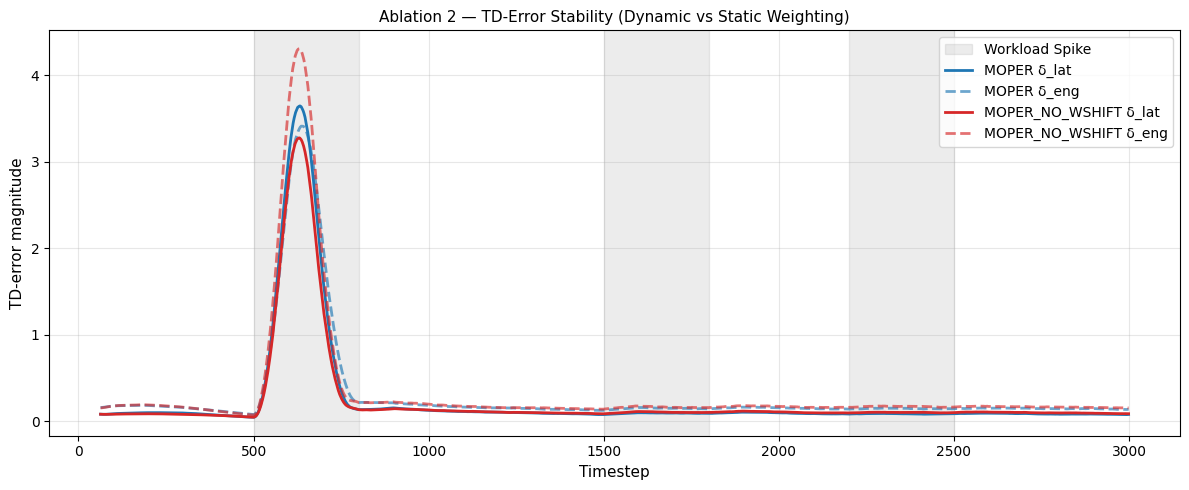

In [26]:
# Cell 15 --- PRIMARY METRIC: TD-Error Stability (Weight Mismatch Proof) (REVISED)
# Applies to MOPER and MOPER_NO_WSHIFT under Ablation 2
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ABLATION2_BENCH_DIR = "results/ablation2/"
SMOOTH = 100

# CORRECTION: Replaced Ablation 1 baseline with the Ablation 2 ablated agent
COLORS = {
    'MOPER': '#1f77b4',         # Blue
    'MOPER_NO_WSHIFT': '#d62728'   # Red
}

SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# Load the consolidated benchmark file for Ablation 2
df = pd.read_csv(f"{ABLATION2_BENCH_DIR}/ablation2_benchmark_raw.csv")

fig, ax = plt.subplots(figsize=(12, 5))

for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: 
        print(f"Warning: No data found for {agent_name}")
        continue
    
    # <- CORRECTED: Group by timestep first so the index is unequivocally chronological
    pivot_lat = sub.groupby(['timestep', 'seed'])['td_lat'].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
    pivot_eng = sub.groupby(['timestep', 'seed'])['td_eng'].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
    
    ax.plot(pivot_lat.mean(axis=1), color=color, lw=2.0, label=f"{agent_name} δ_lat")
    ax.plot(pivot_eng.mean(axis=1), color=color, lw=2.0, ls="--", alpha=0.65, label=f"{agent_name} δ_eng")

ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel('TD-error magnitude', fontsize=11)

# Update title for Ablation 2 context
ax.set_title('Ablation 2 — TD-Error Stability (Dynamic vs Static Weighting)', fontsize=11)

# Prevent duplicate legends from axvspan
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='upper right')

ax.grid(alpha=0.3)
plt.tight_layout()

# Save to correct directory with correct ablation filename
Path(ABLATION2_BENCH_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{ABLATION2_BENCH_DIR}/ablation2_TDError_stability_primary.png", dpi=150)
plt.show()

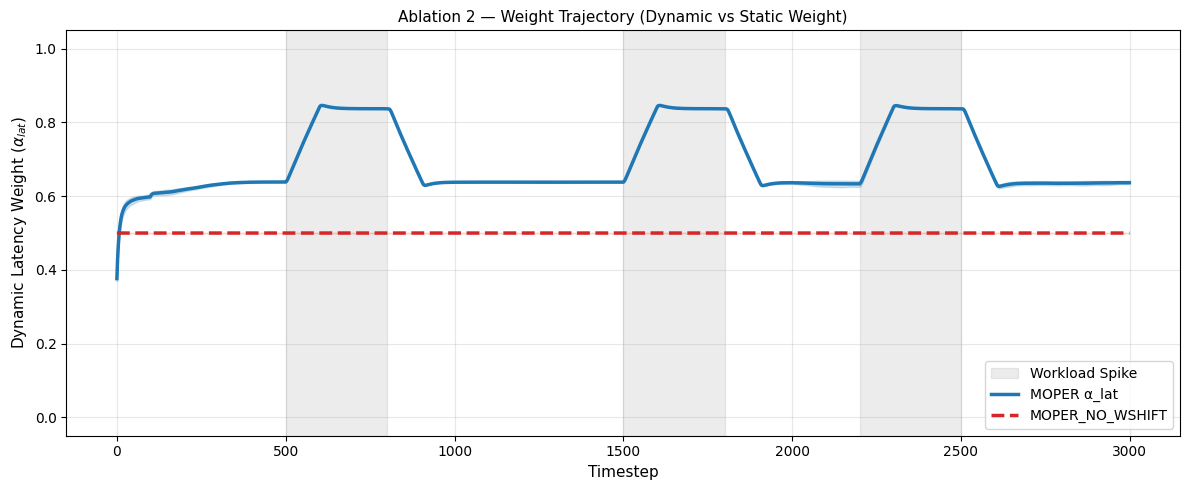

In [1]:
# Cell 16 --- PRIMARY METRIC: Weight Trajectory (α_lat) (REVISED)
# Applies to MOPER and MOPER_NO_WSHIFT to visualize static prioritization
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ABLATION2_BENCH_DIR = "results/ablation2/"
SMOOTH = 100

# CORRECTION: Target the ablated agent and full artifact
COLORS = {
    'MOPER': '#1f77b4',         # Blue
    'MOPER_NO_WSHIFT': '#d62728'   # Red
}

# CORRECTION: Replaced single spike with multi-spike boundaries
SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# CORRECTION: Load the Cell 12 consolidated benchmark file
df = pd.read_csv(f"{ABLATION2_BENCH_DIR}/ablation2_benchmark_raw.csv")

# Ensure canvas width matches previous cells (12, 5)
fig, ax = plt.subplots(figsize=(12, 5))

# Loop generates multiple grey bands for the back-to-back regime changes
for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: 
        print(f"Warning: No data found for {agent_name}")
        continue
    
    # Handle potential column naming variations
    WEIGHT_COL = 'latency_weight' if 'latency_weight' in sub.columns else 'alpha_lat'
    
    # <- CORRECTED: Group by timestep first so the index is unequivocally chronological
    pivot = sub.groupby(['timestep', 'seed'])[WEIGHT_COL].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
    m = pivot.mean(axis=1)
    s = pivot.std(axis=1)
    
    # CORRECTION: Apply standard deviation bounds and distinct linestyles for both agents
    ls = "-" if agent_name == "MOPER" else "--"
    
    # Custom label to clearly mark the static ablation
    display_label = f"{agent_name} α_lat" if agent_name == "MOPER" else f"{agent_name}"
    
    ax.plot(m.index, m.values, label=display_label, color=color, lw=2.5, ls=ls)
    ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.2)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel(r'Dynamic Latency Weight ($\alpha_{lat}$)', fontsize=11)

# CORRECTION: Update title for Ablation 2 context
ax.set_title('Ablation 2 — Weight Trajectory (Dynamic vs Static Weight)', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()

# CORRECTION: Save to correct directory with correct ablation filename
Path(ABLATION2_BENCH_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{ABLATION2_BENCH_DIR}/ablation2_Weight_trajectory_latency_primary.png", dpi=150)
plt.show()

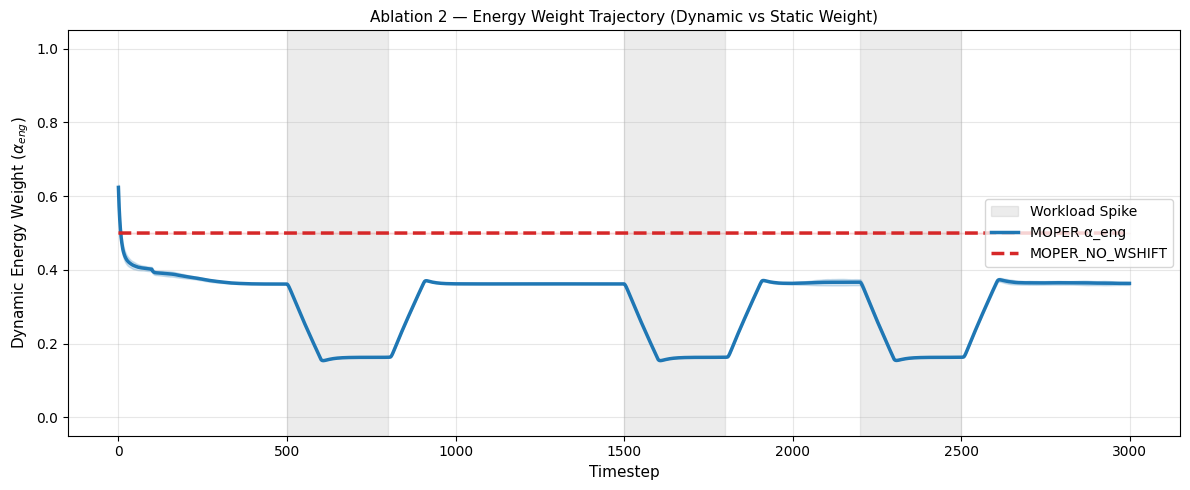

In [ ]:
# Cell 17 --- PRIMARY METRIC: Weight Trajectory (α_eng) (REVISED)
# Applies to MOPER and MOPER_NO_WSHIFT to visualize static prioritization
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ABLATION2_BENCH_DIR = "results/ablation2/"
SMOOTH = 100

# CORRECTION: Target the ablated agent and full artifact
COLORS = {
    'MOPER': '#1f77b4',         # Blue
    'MOPER_NO_WSHIFT': '#d62728'   # Red
}

SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# CORRECTION: Load the Cell 12 consolidated benchmark file
df = pd.read_csv(f"{ABLATION2_BENCH_DIR}/ablation2_benchmark_raw.csv")

fig, ax = plt.subplots(figsize=(12, 5))

for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: 
        print(f"Warning: No data found for {agent_name}")
        continue
    
    # Handle potential column naming variations
    WEIGHT_COL = 'energy_weight' if 'energy_weight' in sub.columns else 'alpha_eng'
    
    # <- CORRECTED: Group by timestep first so the index is unequivocally chronological
    pivot = sub.groupby(['timestep', 'seed'])[WEIGHT_COL].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
    m = pivot.mean(axis=1)
    s = pivot.std(axis=1)
    
    # CORRECTION: Apply standard deviation bounds and distinct linestyles for both agents
    ls = "-" if agent_name == "MOPER" else "--"
    
    # Custom label to clearly mark the static ablation
    display_label = f"{agent_name} α_eng" if agent_name == "MOPER" else f"{agent_name}"
    
    ax.plot(m.index, m.values, label=display_label, color=color, lw=2.5, ls=ls)
    ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.2)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel(r'Dynamic Energy Weight ($\alpha_{eng}$)', fontsize=11)

# CORRECTION: Update title for Ablation 2 context
ax.set_title('Ablation 2 — Energy Weight Trajectory (Dynamic vs Static Weight)', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()

# CORRECTION: Save to correct directory with correct ablation filename
Path(ABLATION2_BENCH_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{ABLATION2_BENCH_DIR}/ablation2_Weight_trajectory_energy_primary.png", dpi=150)
plt.show()